In [6]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#read the data
df=pd.read_csv('1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [9]:
# to check the statistical features of the data
df.describe() #the statistical features are only from numeric variables

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
# to look at variables in detail
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [12]:
# checking whether non numeric variables are categorical in nature
print(df.Car_Name.value_counts())

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64


In [13]:
print(df.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


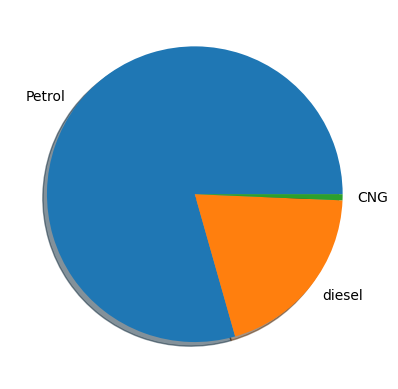

(([<matplotlib.patches.Wedge at 0x20831971c10>,
  [Text(-0.8776154230777207, 0.6631675272328356, 'Petrol'),
   Text(0.8635820276996969, -0.6813413839141726, 'diesel'),
   Text(1.0997603522251278, -0.022960132265800064, 'CNG')]),
 None)

In [17]:
plt.pie(df.Fuel_Type.value_counts(),labels=["Petrol","diesel","CNG"], shadow=True ) ,plt.show()

In [20]:
#1. From which manufacturing year to which year?
df.Year.min(), df.Year.max()

(2003, 2018)

In [21]:
#2. Lowest selling price
df.Selling_Price.min()

0.1

In [22]:
#3. What is the highest price to which a vehicle is sold?
df.Selling_Price.max()

35.0

In [23]:
#4. How many records are there in this data?
df.shape[0]

301

In [24]:
#5. Are there any missing records in this data?
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [25]:
#6. How many different vehicles are present in this data?
df.Car_Name.nunique()

98

In [27]:
#7. Which is the most sold vehicle in this data?
df.Car_Name.value_counts().head(1)

Car_Name
city    26
Name: count, dtype: int64

In [28]:
#8. Does the database include any CNG vehicle? If yes, how many?
(df.Fuel_Type == 'CNG').sum()

2

In [29]:
#9. How many vehicles are for sale from individuals directly?
(df.Seller_Type == 'Individual').sum()

106

In [30]:
#10. Does this database contain automatic transmission vehicles? If yes, how many?
(df.Transmission == 'Automatic').sum()

40

In [31]:
#11. How many single-person-owned vehicles are there?
(df.Owner == 0).sum()

290

In [33]:
#12. Which is the most and least cost-depreciated vehicle?
df['Depreciation'] = df.Present_Price - df.Selling_Price

In [34]:
#Most depreciated vehicle:
df.loc[df.Depreciation.idxmax()]

Car_Name         land cruiser
Year                     2010
Selling_Price            35.0
Present_Price            92.6
Kms_Driven              78000
Fuel_Type              Diesel
Seller_Type            Dealer
Transmission           Manual
Owner                       0
Depreciation             57.6
Name: 86, dtype: object

In [35]:
#Least depreciated vehicle:
df.loc[df.Depreciation.idxmin()]

Car_Name         Honda Activa 4G
Year                        2017
Selling_Price               0.48
Present_Price               0.51
Kms_Driven                  4300
Fuel_Type                 Petrol
Seller_Type           Individual
Transmission           Automatic
Owner                          0
Depreciation                0.03
Name: 155, dtype: object

In [36]:
#If you only want the vehicle name and depreciation:
df.loc[
    df.Depreciation.idxmax(),
    ['Car_Name', 'Depreciation']
]

Car_Name        land cruiser
Depreciation            57.6
Name: 86, dtype: object

In [42]:
#13. Which brand of vehicles are less affected by cost depreciation?
#dataset doesn't have a separate Brand column, so we'll take the first word of Car_Name as the brand.
df['Brand'] = df.Car_Name.str.split().str[0]


In [41]:
#Now calculate average depreciation:
df.groupby('Brand').Depreciation.mean().sort_values()

Brand
UM           0.120000
Activa       0.183333
TVS          0.242750
Mahindra     0.250000
Yamaha       0.258750
Hero         0.265200
Honda        0.318824
Suzuki       0.330000
Bajaj        0.334400
Royal        0.423529
vitara       0.580000
KTM          0.745000
grand        0.756250
ignis        0.810000
alto         1.166667
brio         1.299000
omni         1.440000
i10          1.506000
eon          1.530000
creta        1.800000
swift        1.802000
800          1.930000
wagon        1.937500
baleno       2.020000
Hyosung      2.100000
s            2.110000
xcent        2.163333
ciaz         2.284444
jazz         2.328571
i20          2.438889
ritz         2.475000
amaze        2.564286
etios        2.848182
ertiga       2.848333
dzire        3.157500
elantra      3.190000
verna        3.292143
city         4.372692
sx4          4.908333
innova       5.068889
corolla     10.425882
fortuner    12.047273
camry       21.230000
land        57.600000
Name: Depreciation, dtype:

In [40]:
#To see the brands with the lowest depreciation:
df.groupby('Brand').Depreciation.mean().sort_values().head(10)

Brand
UM          0.120000
Activa      0.183333
TVS         0.242750
Mahindra    0.250000
Yamaha      0.258750
Hero        0.265200
Honda       0.318824
Suzuki      0.330000
Bajaj       0.334400
Royal       0.423529
Name: Depreciation, dtype: float64

In [43]:
#14. Are there any factors which affect cost depreciation?
#First check the correlation:
df[['Year',
    'Kms_Driven',
    'Present_Price',
    'Selling_Price',
    'Depreciation']].corr()


,Year,Kms_Driven,Present_Price,Selling_Price,Depreciation
Year,1.000000,-0.524342,-0.047584,0.236141,-0.333746
Kms_Driven,-0.524342,1.000000,0.203647,0.029187,0.333832
Present_Price,-0.047584,0.203647,1.000000,0.878983,0.864902
Selling_Price,0.236141,0.029187,0.878983,1.000000,0.520881
Depreciation,-0.333746,0.333832,0.864902,0.520881,1.000000


In [44]:
#You can specifically check depreciation:
df[['Year',
    'Kms_Driven',
    'Present_Price',
    'Depreciation']].corr()['Depreciation']

Year            -0.333746
Kms_Driven       0.333832
Present_Price    0.864902
Depreciation     1.000000
Name: Depreciation, dtype: float64

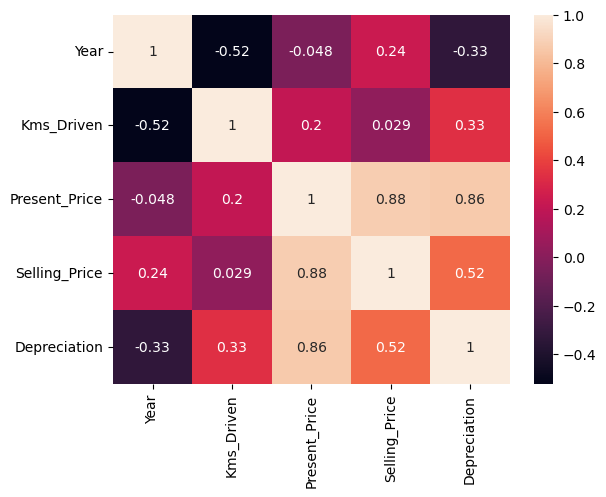

In [45]:
#can also visualize it:
sns.heatmap(
    df[['Year',
        'Kms_Driven',
        'Present_Price',
        'Selling_Price',
        'Depreciation']].corr(),
    annot=True
)

plt.show()

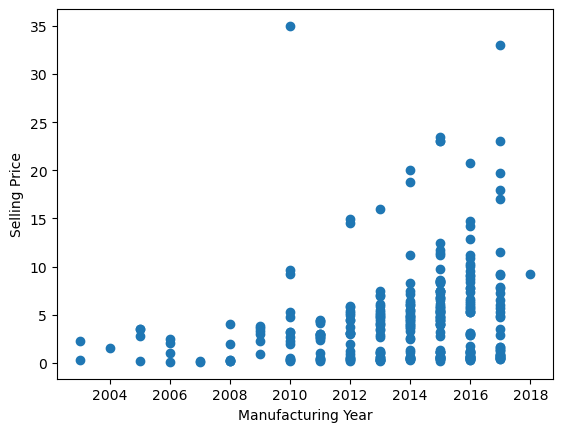

In [46]:
#15. Is selling price affected by age and distance driven?
plt.scatter(
    df.Year,
    df.Selling_Price
)

plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price')

plt.show()

In [47]:
#16. Can we get an idea about newest vehicles, i.e. after 2014?
df[df.Year > 2014].Car_Name

2               ciaz
5      vitara brezza
6               ciaz
7            s cross
8               ciaz
           ...      
295             city
296             city
297             brio
299             city
300             brio
Name: Car_Name, Length: 147, dtype: object

In [49]:
#17. Can we find out data of only two-wheelers?
#In this particular dataset, the two-wheeler records are from row 101 to 201.
two_wheelers = df.iloc[100:201]

two_wheelers

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation,Brand
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,0.15,Royal
101,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,0.12,UM
102,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,0.13,KTM
103,Bajaj Dominar 400,2017,1.45,1.60,1200,Petrol,Individual,Manual,0,0.15,Bajaj
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,0.12,Royal
...,...,...,...,...,...,...,...,...,...,...,...
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0,0.35,Activa
197,Honda CB twister,2010,0.16,0.51,33000,Petrol,Individual,Manual,0,0.35,Honda
198,Bajaj Discover 125,2011,0.15,0.57,35000,Petrol,Individual,Manual,1,0.42,Bajaj
199,Honda CB Shine,2007,0.12,0.58,53000,Petrol,Individual,Manual,0,0.46,Honda


In [50]:
#Check how many:
two_wheelers.shape[0]

101

In [54]:
#18. Which is the oldest bike sold here?
two_wheelers.loc[
    two_wheelers.Year.idxmin(),
    ['Car_Name', 'Year']
]

Car_Name    Hero Super Splendor
Year                       2005
Name: 189, dtype: object

In [53]:
#19. Which is the newest bike sold here?
two_wheelers.loc[
    two_wheelers.Year.idxmax(),
    ['Car_Name', 'Year']
]

Car_Name    UM Renegade Mojave
Year                      2017
Name: 101, dtype: object

In [55]:
#20. Which is the most sold bike here?
two_wheelers.Car_Name.value_counts().head(1)

Car_Name
Royal Enfield Classic 350    7
Name: count, dtype: int64

In [59]:
#21. Do you find any deal in two-wheelers that exceeded the general expectation?
two_wheelers.sort_values(
    'Price_Retention',
    ascending=False
).head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation,Brand,Price_Retention
126,Bajaj Avenger 220,2017,0.90,0.95,1300,Petrol,Individual,Manual,0,0.05,Bajaj,94.736842
155,Honda Activa 4G,2017,0.48,0.51,4300,Petrol,Individual,Automatic,0,0.03,Honda,94.117647
127,Bajaj Avenger 150,2016,0.75,0.80,7000,Petrol,Individual,Manual,0,0.05,Bajaj,93.750000
101,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,0.12,UM,93.406593
129,Yamaha FZ S V 2.0,2017,0.78,0.84,5000,Petrol,Individual,Manual,0,0.06,Yamaha,92.857143
102,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,0.13,KTM,92.696629
156,TVS Sport,2017,0.48,0.52,15000,Petrol,Individual,Manual,0,0.04,TVS,92.307692
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,0.15,Royal,92.105263
128,Honda CB Hornet 160R,2017,0.80,0.87,3000,Petrol,Individual,Manual,0,0.07,Honda,91.954023
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,0.12,Royal,91.836735


In [60]:
#22. Can we find out data of only cars?
cars = pd.concat([
    df.iloc[:100],
    df.iloc[201:]
])

cars
cars.shape[0]

200

In [61]:
#23. Which is the oldest car sold here?
cars.loc[
    cars.Year.idxmin(),
    ['Car_Name', 'Year']
]

Car_Name     800
Year        2003
Name: 37, dtype: object

In [62]:
#24. Which is the newest car sold here?
cars.loc[
    cars.Year.idxmax(),
    ['Car_Name', 'Year']
]

Car_Name    vitara brezza
Year                 2018
Name: 5, dtype: object

In [64]:
#25. Do you find any deal in cars that exceeded the general expectation?
#Create price retention:
cars['Price_Retention'] = (
    cars.Selling_Price /
    cars.Present_Price
) * 100

In [65]:
#Find the best deal:
cars.loc[
    cars.Price_Retention.idxmax()
]

Car_Name           corolla altis
Year                        2016
Selling_Price              14.73
Present_Price              14.89
Kms_Driven                 23000
Fuel_Type                 Diesel
Seller_Type               Dealer
Transmission              Manual
Owner                          0
Depreciation                0.16
Brand                    corolla
Price_Retention        98.925453
Name: 80, dtype: object

In [66]:
#See the important details:
cars.loc[
    cars.Price_Retention.idxmax(),
    ['Car_Name',
     'Year',
     'Selling_Price',
     'Present_Price',
     'Kms_Driven',
     'Owner',
     'Fuel_Type',
     'Transmission',
     'Price_Retention']
]

Car_Name           corolla altis
Year                        2016
Selling_Price              14.73
Present_Price              14.89
Kms_Driven                 23000
Owner                          0
Fuel_Type                 Diesel
Transmission              Manual
Price_Retention        98.925453
Name: 80, dtype: object